# Stage 4 — SHAP Interpretability

This notebook explains the selected XGBoost model on the untouched patient-grouped test set.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results'
FINAL_THRESHOLD = 0.12

pipeline = joblib.load(RESULTS_DIR / 'xgboost.joblib')
xgb_model = pipeline.named_steps['model']
X_test = pd.read_parquet(DATA_DIR / 'X_test.parquet')
y_test = pd.read_parquet(DATA_DIR / 'y_test.parquet')['readmitted_30']

print(f'Test set shape: {X_test.shape}')
print(f'Loaded model type: {type(xgb_model).__name__}')

C:\Users\sagir\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test set shape: (14997, 174)
Loaded model type: XGBClassifier


## Compute exact Tree SHAP values

`TreeExplainer` is used directly on the fitted XGBClassifier, avoiding the slower model-agnostic KernelExplainer.

In [2]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP may return a list for some binary-classifier versions.
if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

print(f'SHAP values shape: {np.asarray(shap_values).shape}')

SHAP values shape: (14997, 174)


## Global feature effects

**Clinical interpretation placeholder:** Describe the leading risk-increasing and risk-decreasing patterns after reviewing this beeswarm plot.

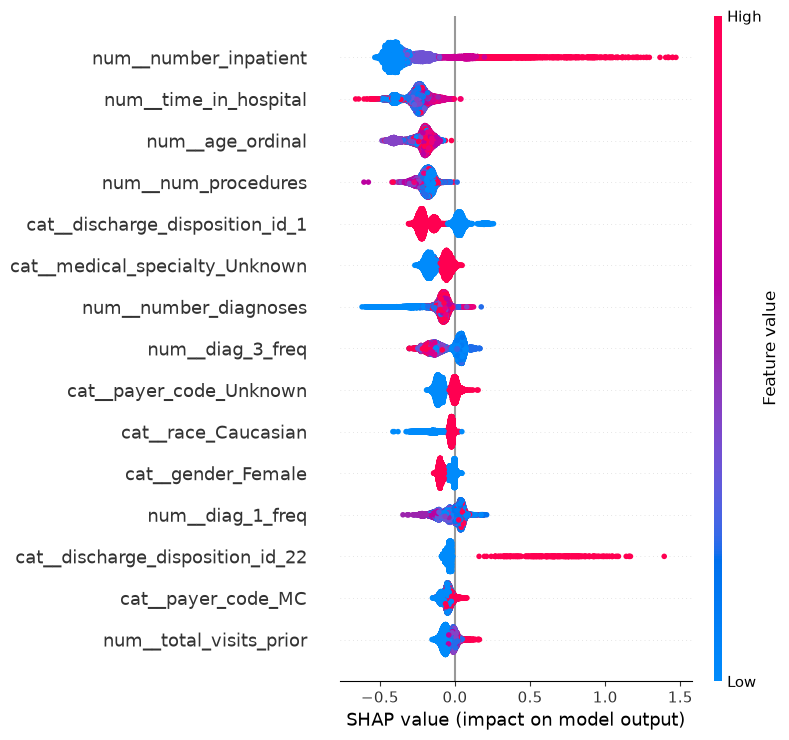

In [3]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Top features by mean absolute SHAP value

In [4]:
top10_features = (
    pd.DataFrame({
        'feature': X_test.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    })
    .sort_values('mean_abs_shap', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_features.to_csv(RESULTS_DIR / 'shap_top10_features.csv', index=False)
print(top10_features.to_string(index=False))

                        feature  mean_abs_shap
          num__number_inpatient       0.347833
          num__time_in_hospital       0.251240
               num__age_ordinal       0.224701
            num__num_procedures       0.192590
cat__discharge_disposition_id_1       0.134874
 cat__medical_specialty_Unknown       0.110636
          num__number_diagnoses       0.101048
               num__diag_3_freq       0.090014
        cat__payer_code_Unknown       0.070798
            cat__race_Caucasian       0.058723


## Select representative patients at the final threshold

Patient A is the highest-probability true positive; Patient B is the highest-probability false negative, if one exists; Patient C is the lowest-probability true negative.

In [5]:
probabilities = xgb_model.predict_proba(X_test)[:, 1]
predicted_high_risk = probabilities >= FINAL_THRESHOLD

true_positive_idx = np.flatnonzero((y_test.to_numpy() == 1) & predicted_high_risk)
false_negative_idx = np.flatnonzero((y_test.to_numpy() == 1) & ~predicted_high_risk)
true_negative_idx = np.flatnonzero((y_test.to_numpy() == 0) & ~predicted_high_risk)

patient_a_idx = true_positive_idx[np.argmax(probabilities[true_positive_idx])]
patient_b_idx = (false_negative_idx[np.argmax(probabilities[false_negative_idx])]
                 if len(false_negative_idx) else None)
patient_c_idx = true_negative_idx[np.argmin(probabilities[true_negative_idx])]

for label, index in [('A — true positive', patient_a_idx),
                     ('B — false negative', patient_b_idx),
                     ('C — true negative', patient_c_idx)]:
    if index is None:
        print(f'Patient {label}: no eligible patient at threshold {FINAL_THRESHOLD:.2f}')
    else:
        print(f'Patient {label}: test-row {index}, probability={probabilities[index]:.4f}, actual={y_test.iloc[index]}')

Patient A — true positive: test-row 4650, probability=0.6185, actual=1
Patient B — false negative: test-row 10437, probability=0.1197, actual=1
Patient C — true negative: test-row 2564, probability=0.0146, actual=0


## Patient A waterfall — true positive

**Clinical interpretation placeholder:** Explain which patient factors drove this correctly identified high-risk prediction.

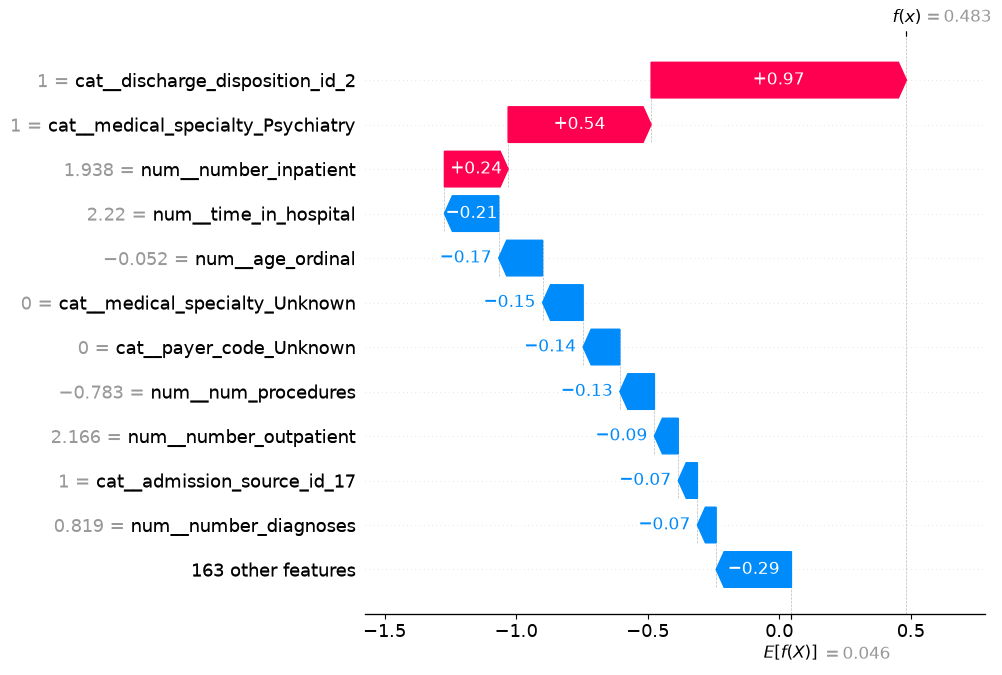

In [6]:
def patient_explanation(index):
    return shap.Explanation(
        values=shap_values[index],
        base_values=explainer.expected_value,
        data=X_test.iloc[index],
        feature_names=X_test.columns.tolist(),
    )

shap.plots.waterfall(patient_explanation(patient_a_idx), max_display=12, show=False)
plt.savefig(RESULTS_DIR / 'shap_waterfall_patient_A_true_positive.png', dpi=300, bbox_inches='tight')
plt.show()

## Patient B waterfall — false negative

**Clinical interpretation placeholder:** Explain why the model may have underestimated risk for this missed readmission.

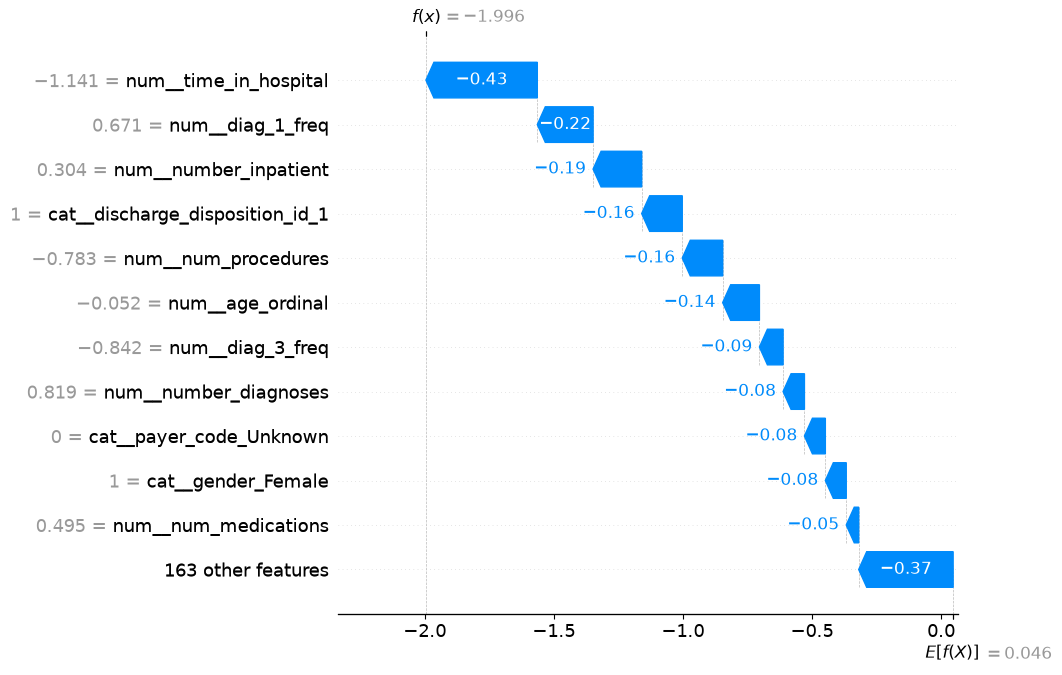

In [7]:
if patient_b_idx is None:
    print(f'No false negatives at threshold {FINAL_THRESHOLD:.2f}; skipping Patient B waterfall plot.')
else:
    shap.plots.waterfall(patient_explanation(patient_b_idx), max_display=12, show=False)
    plt.savefig(RESULTS_DIR / 'shap_waterfall_patient_B_false_negative.png', dpi=300, bbox_inches='tight')
    plt.show()

## Patient C waterfall — true negative

**Clinical interpretation placeholder:** Explain which factors supported the correctly low readmission-risk assessment.

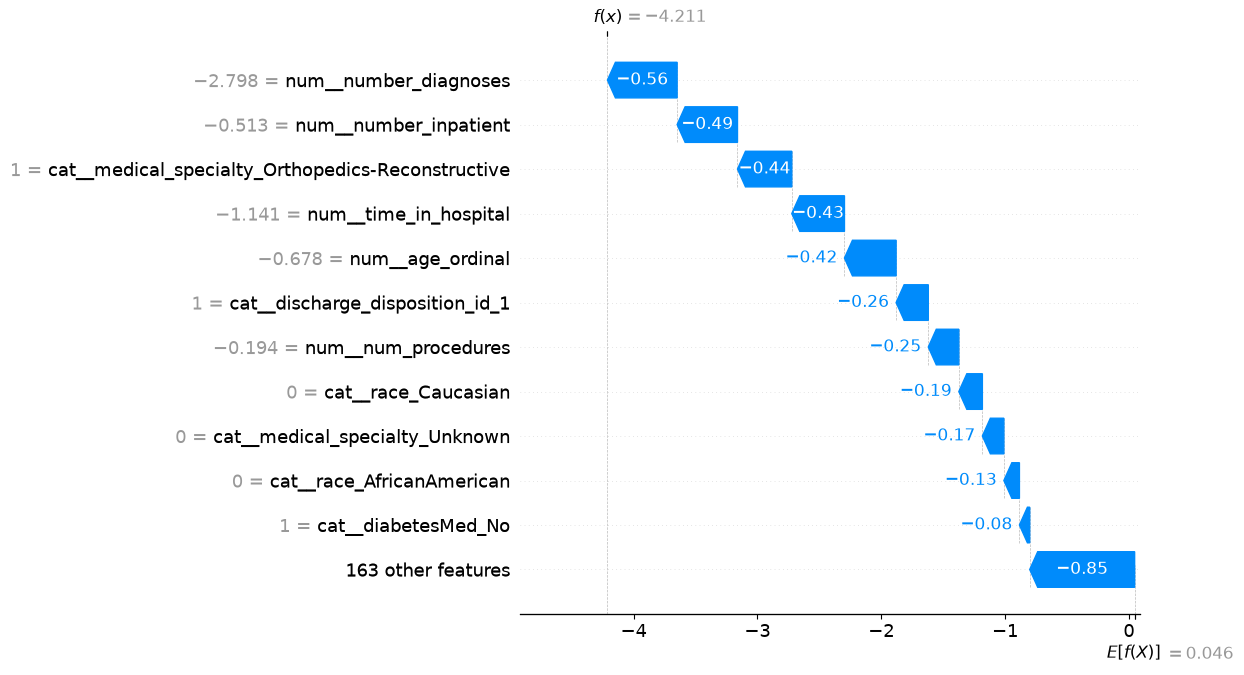

In [8]:
shap.plots.waterfall(patient_explanation(patient_c_idx), max_display=12, show=False)
plt.savefig(RESULTS_DIR / 'shap_waterfall_patient_C_true_negative.png', dpi=300, bbox_inches='tight')
plt.show()